# Regressão de preço de veículos com MLP

Este notebook implementa o trabalho de MLP para estimar `sellingprice` a partir das características e das informações de mercado dos veículos.

> **Integrantes:** Andrey de Matos Gonçalves, Felipe Gabriel Souza Libório, Felipe Vieira Brazão e Silva e Gabriel Coelho Goes.

## Declaração de uso de IA generativa

- **Ferramenta utilizada:** Codex, da OpenAI.
- **Finalidade:** apoiar a estruturação do notebook, a elaboração e revisão do código Python, a organização dos experimentos, a criação de tabelas e gráficos e a redação inicial das interpretações.
- **Extensão aproximada da contribuição:** contribuição substancial, estimada em aproximadamente dois terços da estruturação, do código e da redação inicial deste notebook. A escolha do tema, as decisões finais, a aceitação das alterações e a responsabilidade acadêmica permanecem com a equipe.
- **Medidas de validação:** o código foi executado no ambiente local com sementes fixadas; os resultados numéricos apresentados foram produzidos por execuções reais e conferidos nas tabelas e gráficos; as divisões de treino, validação e teste foram verificadas para evitar uso do holdout durante as buscas; o conteúdo foi confrontado requisito por requisito com a lauda; e cada integrante deve revisar sua análise individual e estar apto a explicar o código, as decisões e os resultados na apresentação.

A IA não substituiu a execução dos experimentos nem a avaliação dos resultados: os textos gerados foram ajustados com base nas saídas efetivamente obtidas. Nenhum resultado numérico foi incluído apenas por estimativa da ferramenta.

## Dataset escolhido e justificativa

- **Nome:** Vehicle Sales and Market Trends Dataset.
- **Fonte:** Kaggle, publicado por Syed Anwar Afridi.
- **Link:** <https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data>
- **Data de acesso/download:** 17/09/2026.
- **Tipo de problema:** regressão supervisionada.
- **Dimensão:** 558.837 instâncias e 16 colunas, correspondentes a 15 atributos preditores potenciais e 1 variável-alvo.
- **Variável-alvo:** `sellingprice`, valor final de venda do veículo, expresso em dólares americanos (US$).
- **Natureza e faixa observada do alvo:** variável numérica contínua, com valores entre US$ 1 e US$ 230.000.
- **Objetivo:** estimar o preço final de venda a partir das características do veículo, de seu estado de conservação e de informações de mercado disponíveis.

Os atributos originais descrevem o veículo (`year`, `make`, `model`, `trim`, `body`, `transmission`, `vin`, `condition`, `odometer`, `color` e `interior`) e o contexto da venda (`state`, `seller`, `mmr` e `saledate`). Durante o pré-processamento, atributos identificadores ou de alta cardinalidade podem ser removidos, e a data de venda pode originar novas variáveis.

O dataset foi escolhido por representar um problema real de regressão, possuir volume suficiente para o treinamento e a validação de uma MLP e combinar variáveis numéricas e categóricas, valores ausentes, escalas distintas e valores extremos. Essas características permitem aplicar e justificar as etapas de análise, pré-processamento, validação cruzada e ajuste de hiperparâmetros solicitadas na atividade. Além disso, ele não corresponde aos datasets utilizados em sala ou expressamente vedados na lauda.

## 1. Configuração e reprodutibilidade

A mesma semente é usada nas divisões e no TensorFlow. O conjunto de teste é separado antes de qualquer ajuste de pré-processamento ou hiperparâmetro.

In [16]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

SEMENTE = 42
CAMINHOS_DADOS = [Path('data/raw/car_prices.csv'), Path('../data/raw/car_prices.csv')]
CAMINHO_DADOS = next(caminho for caminho in CAMINHOS_DADOS if caminho.exists())
TEST_SIZE = 0.20
N_SPLITS_CV = 3
AMOSTRA_CV = 100_000  # reduz o custo da busca; sempre retirada somente do treino

random.seed(SEMENTE)
np.random.seed(SEMENTE)
tf.keras.utils.set_random_seed(SEMENTE)

print(f'Python/ambiente | scikit-learn={sklearn.__version__} | TensorFlow={tf.__version__}')

Python/ambiente | scikit-learn=1.5.2 | TensorFlow=2.19.1


## 2. Carregamento e diagnóstico inicial

O arquivo original não é alterado. A inspeção a seguir documenta dimensões, tipos, ausências e duplicatas para orientar o pré-processamento.

In [17]:
dados = pd.read_csv(CAMINHO_DADOS, low_memory=False)
print(f'Dimensões: {dados.shape[0]:,} linhas × {dados.shape[1]} colunas')
display(dados.head())
display(pd.DataFrame({
    'tipo': dados.dtypes.astype(str),
    'ausentes': dados.isna().sum(),
    'ausentes_%': (dados.isna().mean() * 100).round(2),
    'valores_unicos': dados.nunique(dropna=True),
}).sort_values('ausentes_%', ascending=False))
print(f'Duplicatas completas: {dados.duplicated().sum():,}')

Dimensões: 558,837 linhas × 16 colunas


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


,tipo,ausentes,ausentes_%,valores_unicos
transmission,str,65352,11.69,4
body,str,13195,2.36,87
condition,float64,11820,2.12,41
trim,str,10651,1.91,1963
model,str,10399,1.86,973
make,str,10301,1.84,96
color,str,749,0.13,46
interior,str,749,0.13,17
odometer,float64,94,0.02,172278
mmr,float64,38,0.01,1101


Duplicatas completas: 0


## 3. Variável-alvo

Para regressão, serão usadas MAE como métrica principal, RMSE como penalização adicional para erros grandes e R² como proporção de variabilidade explicada. Antes do treinamento, verificamos a escala, dispersão e valores extremos de `sellingprice`.

,sellingprice
count,558825.000000
mean,13611.358810
std,9749.501628
min,1.000000
1%,500.000000
5%,1500.000000
50%,12100.000000
95%,30600.000000
99%,44900.000000
max,230000.000000


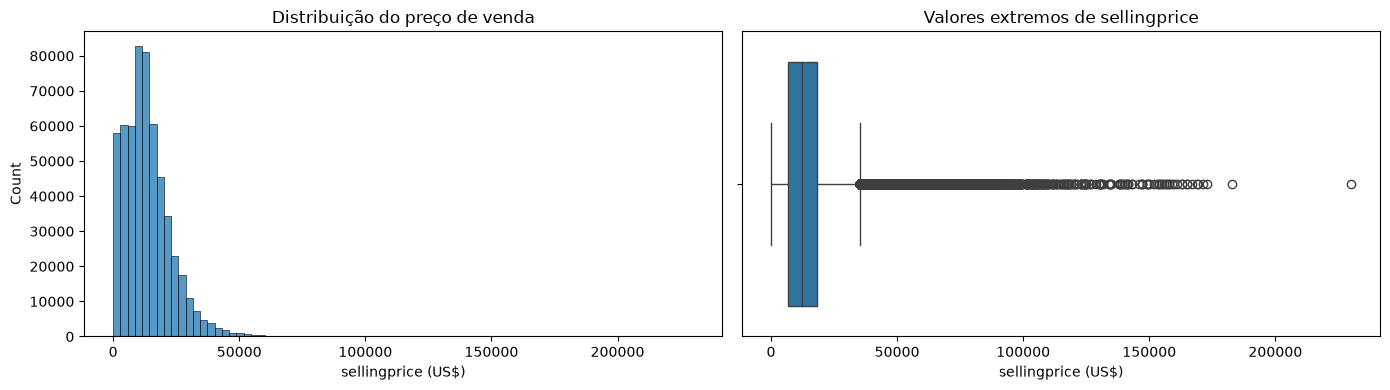

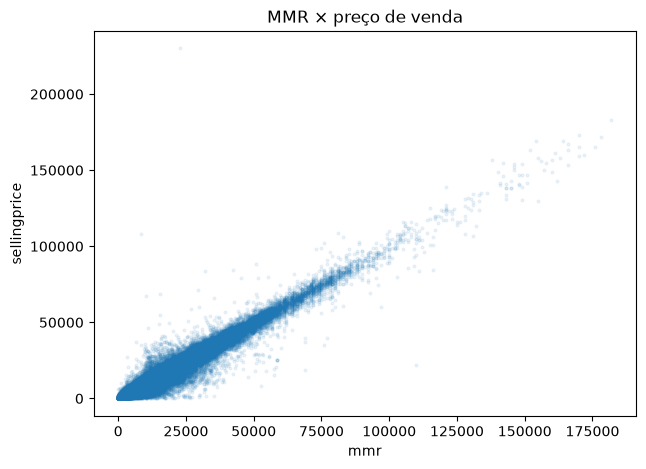

In [18]:
alvo = 'sellingprice'
display(dados[alvo].describe(percentiles=[.01, .05, .50, .95, .99]).to_frame('sellingprice'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(dados[alvo].dropna(), bins=80, ax=axes[0])
axes[0].set(title='Distribuição do preço de venda', xlabel='sellingprice (US$)')
sns.boxplot(x=dados[alvo].dropna(), ax=axes[1])
axes[1].set(title='Valores extremos de sellingprice', xlabel='sellingprice (US$)')
plt.tight_layout()

dados.plot.scatter(x='mmr', y=alvo, alpha=0.08, s=4, figsize=(7, 5), title='MMR × preço de venda')
plt.show()

## 4. Preparação de atributos e holdout

`vin` é removido por ser quase único. `saledate` é convertido em ano, mês e dia da semana. A coluna `seller` fica inicialmente fora da MLP por possuir alta cardinalidade; essa decisão reduz dimensionalidade e evita memorizar vendedores. `mmr` é mantida nesta primeira versão, mas seu possível vazamento de informação será discutido e comparado posteriormente com uma versão sem essa variável.

A separação é estratificada por faixas de preço obtidas por quantis, preservando aproximadamente a distribuição do alvo no teste.

In [19]:
def preparar_atributos(df, incluir_mmr=True):
    """Cria atributos determinísticos, sem ajustar estatísticas aos dados."""
    resultado = df.copy()
    data_venda = pd.to_datetime(resultado['saledate'], format='mixed', errors='coerce', utc=True)
    resultado['sale_year'] = data_venda.dt.year
    resultado['sale_month'] = data_venda.dt.month
    resultado['sale_dayofweek'] = data_venda.dt.dayofweek
    resultado = resultado.drop(columns=['vin', 'saledate', 'seller'])
    if not incluir_mmr:
        resultado = resultado.drop(columns=['mmr'])
    return resultado

dados_modelagem = dados.dropna(subset=[alvo]).copy()
X = preparar_atributos(dados_modelagem.drop(columns=alvo), incluir_mmr=True)
y = dados_modelagem[alvo].astype('float32')

faixas_preco = pd.qcut(y, q=10, labels=False, duplicates='drop')
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEMENTE, stratify=faixas_preco
)
print(f'Treino: {X_treino.shape[0]:,} linhas | Teste reservado: {X_teste.shape[0]:,} linhas')
print('O conjunto de teste não será usado até a avaliação final.')

Treino: 447,060 linhas | Teste reservado: 111,765 linhas
O conjunto de teste não será usado até a avaliação final.


## 5. Pipeline de pré-processamento

Todas as imputações, a codificação e a escala são ajustadas dentro do pipeline. Portanto, em cada fold da validação cruzada, elas aprendem exclusivamente com a parte de treinamento daquele fold. Categorias raras são agrupadas para controlar o número de entradas da MLP.

In [20]:
colunas_numericas = X_treino.select_dtypes(include=np.number).columns.tolist()
colunas_categoricas = X_treino.select_dtypes(exclude=np.number).columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        ('numericas', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('float32', FunctionTransformer(lambda x: x.astype(np.float32))),
        ]), colunas_numericas),
        ('categoricas', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(
                handle_unknown='infrequent_if_exist', min_frequency=100, max_categories=50,
                sparse_output=False, dtype=np.float32
            )),
        ]), colunas_categoricas),
    ],
    remainder='drop',
)

print('Numéricas:', colunas_numericas)
print('Categóricas:', colunas_categoricas)

Numéricas: ['year', 'condition', 'odometer', 'mmr', 'sale_year', 'sale_month', 'sale_dayofweek']
Categóricas: ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']


## 6. MLP de referência e validação cruzada

Antes das buscas, treinamos uma MLP de referência. Para que a busca posterior seja executável em CPU, a validação cruzada usa uma amostra estratificada de 100.000 observações retirada exclusivamente de `X_treino`. O conjunto de teste permanece intocado.

Como o preço possui escala ampla e assimetria, a rede aprende `log1p(sellingprice)`. As previsões são convertidas novamente para dólares antes do cálculo de MAE, RMSE e R².

In [21]:
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

def criar_mlp(n_entradas, camadas=(64, 32), ativacao='relu', learning_rate=1e-3, otimizador='adam'):
    """Cria uma MLP densa com saída linear para regressão."""
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEMENTE)
    modelo = tf.keras.Sequential([tf.keras.layers.Input(shape=(n_entradas,))])
    for neuronios in camadas:
        modelo.add(tf.keras.layers.Dense(neuronios, activation=ativacao))
    modelo.add(tf.keras.layers.Dense(1, activation='linear'))

    classe_otimizador = tf.keras.optimizers.get(otimizador).__class__
    modelo.compile(
        optimizer=classe_otimizador(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'],
    )
    return modelo

CONFIG_REFERENCIA = {
    'camadas': (64, 32),
    'ativacao': 'relu',
    'learning_rate': 1e-3,
    'otimizador': 'adam',
    'batch_size': 128,
    'epocas': 80,
    'paciencia': 12,
}
CONFIG_REFERENCIA

{'camadas': (64, 32),
 'ativacao': 'relu',
 'learning_rate': 0.001,
 'otimizador': 'adam',
 'batch_size': 128,
 'epocas': 80,
 'paciencia': 12}

In [22]:
# Amostra estratificada retirada apenas do conjunto de treinamento.
if AMOSTRA_CV and AMOSTRA_CV < len(X_treino):
    faixas_treino = pd.qcut(y_treino, q=10, labels=False, duplicates='drop')
    X_cv, _, y_cv, _ = train_test_split(
        X_treino, y_treino, train_size=AMOSTRA_CV,
        random_state=SEMENTE, stratify=faixas_treino,
    )
else:
    X_cv, y_cv = X_treino.copy(), y_treino.copy()

print(f'Amostra para CV: {len(X_cv):,} linhas')

Amostra para CV: 100,000 linhas


In [23]:
def avaliar_configuracao_cv(configuracao, X_dados, y_dados, n_splits=N_SPLITS_CV, verbose=0, preprocessador_base=None):
    """Avalia uma configuração sem usar o holdout e retorna métricas em dólares."""
    if preprocessador_base is None:
        preprocessador_base = preprocessador
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEMENTE)
    resultados = []

    for fold, (idx_treino, idx_validacao) in enumerate(kfold.split(X_dados), start=1):
        X_fold_treino, X_fold_validacao = X_dados.iloc[idx_treino], X_dados.iloc[idx_validacao]
        y_fold_treino, y_fold_validacao = y_dados.iloc[idx_treino], y_dados.iloc[idx_validacao]

        # Validação interna para o EarlyStopping, separada do fold avaliado.
        faixas_internas = pd.qcut(y_fold_treino, q=10, labels=False, duplicates='drop')
        X_ajuste, X_parada, y_ajuste, y_parada = train_test_split(
            X_fold_treino, y_fold_treino, test_size=0.10,
            random_state=SEMENTE + fold, stratify=faixas_internas,
        )

        prep_fold = clone(preprocessador_base)
        X_ajuste_proc = prep_fold.fit_transform(X_ajuste)
        X_parada_proc = prep_fold.transform(X_parada)
        X_validacao_proc = prep_fold.transform(X_fold_validacao)

        modelo = criar_mlp(X_ajuste_proc.shape[1], **{
            chave: configuracao[chave]
            for chave in ['camadas', 'ativacao', 'learning_rate', 'otimizador']
        })
        parada = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=configuracao['paciencia'], restore_best_weights=True
        )
        parar_se_nan = tf.keras.callbacks.TerminateOnNaN()
        historico = modelo.fit(
            X_ajuste_proc, np.log1p(y_ajuste),
            validation_data=(X_parada_proc, np.log1p(y_parada)),
            epochs=configuracao['epocas'], batch_size=configuracao['batch_size'],
            callbacks=[parada, parar_se_nan], verbose=verbose,
        )
        # Evita overflow em expm1 se uma previsão em escala logarítmica for extrema.
        limite_log = np.log1p(y_ajuste.max() * 2)
        previsoes_log = modelo.predict(X_validacao_proc, verbose=0).ravel()
        previsoes_log = np.nan_to_num(previsoes_log, nan=0.0, posinf=limite_log, neginf=0.0)
        previsoes = np.expm1(np.clip(previsoes_log, 0.0, limite_log))
        resultados.append({
            'fold': fold,
            'mae': mean_absolute_error(y_fold_validacao, previsoes),
            'rmse': root_mean_squared_error(y_fold_validacao, previsoes),
            'r2': r2_score(y_fold_validacao, previsoes),
            'epocas_treinadas': len(historico.history['loss']),
        })

    return pd.DataFrame(resultados)

In [24]:
resultados_referencia = avaliar_configuracao_cv(CONFIG_REFERENCIA, X_cv, y_cv, verbose=0)
display(resultados_referencia)
resumo_referencia = resultados_referencia[['mae', 'rmse', 'r2', 'epocas_treinadas']].agg(['mean', 'std']).T
display(resumo_referencia)

,fold,mae,rmse,r2,epocas_treinadas
0,1,1412.213745,3214.277100,0.893419,17
1,2,1311.294678,2648.392334,0.926916,30
2,3,1350.670044,2792.832764,0.917018,32


,mean,std
mae,1358.059448,50.863716
rmse,2885.167236,294.024933
r2,0.912451,0.017209
epocas_treinadas,26.333333,8.144528


### Interpretação da referência

Registrar após executar: a média e o desvio-padrão do MAE entre os folds; se as épocas variaram muito; e sinais de underfitting ou overfitting. Esses resultados formam uma referência para interpretar a Random Search e o TPE, não uma avaliação final no teste.

## 7. Espaço comum de busca

Random Search e TPE usarão a mesma amostra `X_cv`, os mesmos 3 folds, o mesmo MAE como critério de seleção e o mesmo orçamento de 25 tentativas. O holdout continuará reservado até a configuração final.

## 8. Random Search — baseline

A função abaixo sorteia 25 configurações independentes. Não execute as duas buscas ao mesmo tempo: cada uma realiza 75 treinamentos (25 tentativas × 3 folds).

In [25]:
import gc
import optuna
from optuna.importance import get_param_importances

N_TRIALS = 25
ESPACO_BUSCA = {
    'n_camadas': [1, 2, 3], 'neuronios': [32, 64, 128, 256],
    'ativacao': ['relu', 'tanh'], 'learning_rate': (1e-4, 1e-2),
    'batch_size': [32, 64, 128], 'otimizador': ['adam', 'rmsprop'],
    'paciencia': [8, 12, 16, 20], 'epocas': 80,
}

def configurar_rede(parametros):
    camadas = tuple(parametros[f'neuronios_{i}'] for i in range(1, parametros['n_camadas'] + 1))
    return {
        'camadas': camadas, 'ativacao': parametros['ativacao'],
        'learning_rate': parametros['learning_rate'], 'otimizador': parametros['otimizador'],
        'batch_size': parametros['batch_size'], 'epocas': ESPACO_BUSCA['epocas'],
        'paciencia': parametros['paciencia'],
    }

def registrar_resultado(numero, parametros, folds):
    medias = folds[['mae', 'rmse', 'r2', 'epocas_treinadas']].mean().to_dict()
    return {
        'tentativa': numero, **parametros, 'camadas_efetivas': configurar_rede(parametros)['camadas'],
        **{f'{nome}_medio': valor for nome, valor in medias.items()},
        'mae_desvio': folds['mae'].std(),
    }

def sortear_parametros(rng):
    return {
        'n_camadas': int(rng.choice(ESPACO_BUSCA['n_camadas'])),
        'neuronios_1': int(rng.choice(ESPACO_BUSCA['neuronios'])),
        'neuronios_2': int(rng.choice(ESPACO_BUSCA['neuronios'])),
        'neuronios_3': int(rng.choice(ESPACO_BUSCA['neuronios'])),
        'ativacao': str(rng.choice(ESPACO_BUSCA['ativacao'])),
        'learning_rate': float(10 ** rng.uniform(-4, -2)),
        'batch_size': int(rng.choice(ESPACO_BUSCA['batch_size'])),
        'otimizador': str(rng.choice(ESPACO_BUSCA['otimizador'])),
        'paciencia': int(rng.choice(ESPACO_BUSCA['paciencia'])),
    }

def executar_random_search(n_trials=N_TRIALS):
    rng, registros = np.random.default_rng(SEMENTE), []
    for numero in range(1, n_trials + 1):
        parametros = sortear_parametros(rng)
        folds = avaliar_configuracao_cv(configurar_rede(parametros), X_cv, y_cv, verbose=0)
        registro = registrar_resultado(numero, parametros, folds)
        registros.append(registro)
        print(f"Random {numero:02d}/{n_trials}: MAE médio = US$ {registro['mae_medio']:,.2f}")
        gc.collect()
    return pd.DataFrame(registros).sort_values('mae_medio').reset_index(drop=True)

c:\Users\PC\trabalho-mlp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
# Altere para True quando estiver pronto para executar os 25 trials.
EXECUTAR_RANDOM_SEARCH = True
if EXECUTAR_RANDOM_SEARCH:
    resultados_random = executar_random_search()
    display(resultados_random.head(10))
else:
    print('Random Search não executada. Defina EXECUTAR_RANDOM_SEARCH = True para iniciar.')

Random 01/25: MAE médio = US$ 1,468.92
Random 02/25: MAE médio = US$ 1,027.26
Random 03/25: MAE médio = US$ 1,523.22
Random 04/25: MAE médio = US$ 1,286.24
Random 05/25: MAE médio = US$ 1,375.43
Random 06/25: MAE médio = US$ 1,156.89
Random 07/25: MAE médio = US$ 1,474.04
Random 08/25: MAE médio = US$ 1,118.88
Random 09/25: MAE médio = US$ 1,140.80
Random 10/25: MAE médio = US$ 1,310.62
Random 11/25: MAE médio = US$ 1,229.16
Random 12/25: MAE médio = US$ 1,171.35
Random 13/25: MAE médio = US$ 1,404.64
Random 14/25: MAE médio = US$ 1,077.81
Random 15/25: MAE médio = US$ 1,071.23
Random 16/25: MAE médio = US$ 1,337.39
Random 17/25: MAE médio = US$ 1,340.95
Random 18/25: MAE médio = US$ 1,186.26
Random 19/25: MAE médio = US$ 1,371.96
Random 20/25: MAE médio = US$ 1,067.48
Random 21/25: MAE médio = US$ 1,412.67
Random 22/25: MAE médio = US$ 1,167.76
Random 23/25: MAE médio = US$ 1,237.57
Random 24/25: MAE médio = US$ 1,456.25
Random 25/25: MAE médio = US$ 1,211.45


,tentativa,n_camadas,neuronios_1,neuronios_2,neuronios_3,ativacao,learning_rate,batch_size,otimizador,paciencia,camadas_efetivas,mae_medio,rmse_medio,r2_medio,epocas_treinadas_medio,mae_desvio
0,2,2,256,128,256,tanh,0.000180,128,rmsprop,12,"(256, 128)",1027.257935,1632.175781,0.972121,80.000000,13.786657
1,20,3,128,128,64,tanh,0.000172,32,adam,20,"(128, 128, 64)",1067.481812,1795.704956,0.966274,41.333333,24.875315
2,15,3,32,64,64,tanh,0.000294,128,rmsprop,8,"(32, 64, 64)",1071.230225,1834.983398,0.964771,74.666667,27.254702
3,14,2,128,32,128,tanh,0.000115,32,adam,12,"(128, 32)",1077.814453,1791.884155,0.966416,52.333333,12.575126
4,8,3,32,64,32,tanh,0.000284,64,rmsprop,16,"(32, 64, 32)",1118.881226,2057.203857,0.955747,74.666667,36.798832
5,9,3,64,32,256,tanh,0.000421,128,rmsprop,20,"(64, 32, 256)",1140.803101,2131.639648,0.952298,59.333333,36.549774
6,6,3,32,64,64,relu,0.000204,32,rmsprop,16,"(32, 64, 64)",1156.887085,2285.672607,0.943640,53.000000,78.592270
7,22,1,128,256,64,tanh,0.000156,32,adam,20,"(128,)",1167.764404,1762.145996,0.967526,80.000000,17.653603
8,12,1,256,128,64,tanh,0.000190,64,adam,8,"(256,)",1171.349121,1774.965942,0.967045,80.000000,34.540512
9,18,1,32,256,128,tanh,0.000210,64,rmsprop,16,"(32,)",1186.260254,2430.624268,0.938180,80.000000,10.850809


In [27]:
def sugerir_parametros_tpe(trial):
    return {
        'n_camadas': trial.suggest_categorical('n_camadas', ESPACO_BUSCA['n_camadas']),
        'neuronios_1': trial.suggest_categorical('neuronios_1', ESPACO_BUSCA['neuronios']),
        'neuronios_2': trial.suggest_categorical('neuronios_2', ESPACO_BUSCA['neuronios']),
        'neuronios_3': trial.suggest_categorical('neuronios_3', ESPACO_BUSCA['neuronios']),
        'ativacao': trial.suggest_categorical('ativacao', ESPACO_BUSCA['ativacao']),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', ESPACO_BUSCA['batch_size']),
        'otimizador': trial.suggest_categorical('otimizador', ESPACO_BUSCA['otimizador']),
        'paciencia': trial.suggest_categorical('paciencia', ESPACO_BUSCA['paciencia']),
    }

def executar_tpe(n_trials=N_TRIALS):
    registros = []
    estudo = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEMENTE))
    def objetivo(trial):
        parametros = sugerir_parametros_tpe(trial)
        folds = avaliar_configuracao_cv(configurar_rede(parametros), X_cv, y_cv, verbose=0)
        registro = registrar_resultado(trial.number + 1, parametros, folds)
        registros.append(registro)
        trial.set_user_attr('rmse_medio', registro['rmse_medio'])
        trial.set_user_attr('r2_medio', registro['r2_medio'])
        print(f"TPE {trial.number + 1:02d}/{n_trials}: MAE médio = US$ {registro['mae_medio']:,.2f}")
        gc.collect()
        return registro['mae_medio']
    estudo.optimize(objetivo, n_trials=n_trials)
    return estudo, pd.DataFrame(registros).sort_values('mae_medio').reset_index(drop=True)

# O TPE deve ser executado depois da Random Search.
EXECUTAR_TPE = True
if EXECUTAR_TPE:
    estudo_tpe, resultados_tpe = executar_tpe()
    display(resultados_tpe.head(10))
else:
    print('TPE não executado. Defina EXECUTAR_TPE = True para iniciar.')

[I 2026-09-18 13:57:57,591] A new study created in memory with name: no-name-0cc54d63-0ee5-4135-9cb6-684d7538a7fb


TPE 01/25: MAE médio = US$ 1,162.06


[I 2026-09-18 13:59:19,737] Trial 0 finished with value: 1162.0556640625 and parameters: {'n_camadas': 2, 'neuronios_1': 32, 'neuronios_2': 32, 'neuronios_3': 32, 'ativacao': 'tanh', 'learning_rate': 0.0011207606211860567, 'batch_size': 128, 'otimizador': 'rmsprop', 'paciencia': 16}. Best is trial 0 with value: 1162.0556640625.
[I 2026-09-18 14:02:15,845] Trial 1 finished with value: 1146.1405029296875 and parameters: {'n_camadas': 2, 'neuronios_1': 256, 'neuronios_2': 32, 'neuronios_3': 32, 'ativacao': 'tanh', 'learning_rate': 0.00032927591344236165, 'batch_size': 32, 'otimizador': 'adam', 'paciencia': 8}. Best is trial 1 with value: 1146.1405029296875.


TPE 02/25: MAE médio = US$ 1,146.14
TPE 03/25: MAE médio = US$ 1,243.65


[I 2026-09-18 14:05:15,529] Trial 2 finished with value: 1243.6494140625 and parameters: {'n_camadas': 2, 'neuronios_1': 256, 'neuronios_2': 64, 'neuronios_3': 128, 'ativacao': 'relu', 'learning_rate': 0.00024970737145052745, 'batch_size': 64, 'otimizador': 'rmsprop', 'paciencia': 20}. Best is trial 1 with value: 1146.1405029296875.


...

TPE 23/25: MAE médio = US$ 1,073.41


[I 2026-09-18 15:00:21,547] Trial 23 finished with value: 1094.7685546875 and parameters: {'n_camadas': 1, 'neuronios_1': 128, 'neuronios_2': 32, 'neuronios_3': 128, 'ativacao': 'relu', 'learning_rate': 0.00017732286930269552, 'batch_size': 128, 'otimizador': 'rmsprop', 'paciencia': 8}. Best is trial 15 with value: 1072.109130859375.


TPE 24/25: MAE médio = US$ 1,094.77
TPE 25/25: MAE médio = US$ 1,073.10


[I 2026-09-18 15:03:04,854] Trial 24 finished with value: 1073.09521484375 and parameters: {'n_camadas': 1, 'neuronios_1': 128, 'neuronios_2': 32, 'neuronios_3': 128, 'ativacao': 'relu', 'learning_rate': 0.00010466694836305312, 'batch_size': 128, 'otimizador': 'rmsprop', 'paciencia': 8}. Best is trial 15 with value: 1072.109130859375.


,tentativa,n_camadas,neuronios_1,neuronios_2,neuronios_3,ativacao,learning_rate,batch_size,otimizador,paciencia,camadas_efetivas,mae_medio,rmse_medio,r2_medio,epocas_treinadas_medio,mae_desvio
0,16,1,128,32,128,relu,0.000119,128,rmsprop,8,"(128,)",1072.109131,1972.512695,0.958196,80.000000,11.579367
1,22,1,128,32,128,relu,0.000106,128,rmsprop,8,"(128,)",1072.531616,1952.986938,0.958892,80.000000,10.964025
2,17,1,128,32,128,relu,0.000106,128,rmsprop,8,"(128,)",1072.808472,1949.494141,0.959012,80.000000,10.573153
3,15,1,128,32,128,relu,0.000109,128,rmsprop,8,"(128,)",1072.895630,1944.589722,0.959206,80.000000,9.992090
4,25,1,128,32,128,relu,0.000105,128,rmsprop,8,"(128,)",1073.095215,1970.091187,0.958270,80.000000,11.416182
5,4,1,128,32,128,relu,0.000112,128,rmsprop,8,"(128,)",1073.245239,1957.656250,0.958667,80.000000,8.272097
6,23,1,128,32,128,relu,0.000110,128,rmsprop,8,"(128,)",1073.406372,1972.516479,0.958184,80.000000,8.545164
7,24,1,128,32,128,relu,0.000177,128,rmsprop,8,"(128,)",1094.768555,1938.816406,0.959324,75.666667,31.084444
8,20,1,128,128,128,relu,0.000266,128,rmsprop,8,"(128,)",1105.844604,1962.230835,0.958526,56.000000,27.790932
9,18,1,128,32,256,relu,0.000360,128,rmsprop,8,"(128,)",1128.088745,1739.615723,0.968355,51.333333,13.700308


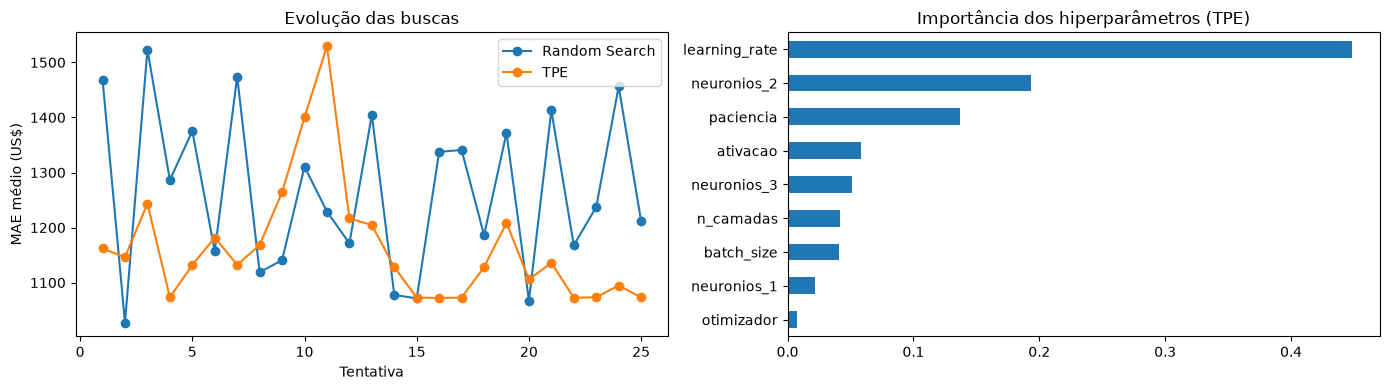

In [28]:
if 'resultados_random' in globals() and 'resultados_tpe' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for tabela, nome in [(resultados_random, 'Random Search'), (resultados_tpe, 'TPE')]:
        tabela = tabela.sort_values('tentativa')
        axes[0].plot(tabela['tentativa'], tabela['mae_medio'], marker='o', label=nome)
    axes[0].set(xlabel='Tentativa', ylabel='MAE médio (US$)', title='Evolução das buscas')
    axes[0].legend()
    pd.Series(get_param_importances(estudo_tpe)).sort_values().plot.barh(ax=axes[1])
    axes[1].set_title('Importância dos hiperparâmetros (TPE)')
    plt.tight_layout()
else:
    print('Execute as duas buscas antes de gerar a comparação.')

## 9. Comparação crítica entre Random Search e TPE

A comparação foi controlada: as duas estratégias usaram a mesma amostra de 100.000 registros retirada exclusivamente do conjunto de treino, os mesmos três folds, o mesmo espaço de hiperparâmetros, o MAE em dólares como critério e o mesmo orçamento de 25 configurações. O conjunto de teste reservado não participou de nenhuma busca.

### Melhores configurações

| Estratégia | Tentativa da melhor | Camadas ocultas | Ativação | Learning rate | Batch size | Otimizador | Paciência | MAE médio (US$) | Desvio do MAE | RMSE médio (US$) | R² médio |
|---|---:|---|---|---:|---:|---|---:|---:|---:|---:|---:|
| **Random Search** | 2 | 256, 128 | `tanh` | 0,0001804 | 128 | RMSprop | 12 | **1.027,26** | 13,79 | **1.632,18** | **0,9721** |
| TPE | 16 | 128 | `relu` | 0,0001195 | 128 | RMSprop | 8 | 1.072,11 | **11,58** | 1.972,51 | 0,9582 |

A Random Search encontrou o menor MAE de validação. A diferença foi de US$ 44,85, equivalente a aproximadamente 4,2% do MAE da melhor configuração do TPE. Ela também obteve RMSE US$ 340,34 menor e R² cerca de 0,014 maior. O melhor resultado do TPE apresentou desvio de MAE ligeiramente menor entre os folds, mas essa pequena vantagem de estabilidade não compensou seu erro médio superior. Por esse motivo, a configuração da Random Search foi selecionada para o treinamento final.

### Comportamento das 25 tentativas

| Estratégia | MAE médio das tentativas (US$) | Mediana (US$) | Desvio entre tentativas (US$) | Melhor (US$) | Pior (US$) |
|---|---:|---:|---:|---:|---:|
| Random Search | 1.265,05 | 1.237,57 | 146,19 | **1.027,26** | 1.523,22 |
| TPE | **1.163,74** | **1.132,26** | **108,91** | 1.072,11 | 1.529,48 |

Embora a Random Search tenha produzido a melhor configuração isolada logo na tentativa 2, seus resultados foram mais dispersos e, em média, piores. O TPE começou com explorações variadas e, após acumular observações, concentrou várias tentativas na região de uma camada com 128 neurônios, `relu`, RMSprop, lote 128 e learning rate baixo. Assim, o TPE foi mais consistente no conjunto das 25 avaliações, mas convergiu para uma região local cujo melhor resultado não superou o achado excepcional da busca aleatória. Com apenas 25 trials e um espaço misto de variáveis contínuas, categóricas e condicionais, esse comportamento é plausível: a adaptação melhora a frequência de boas configurações, mas não garante encontrar o melhor ponto global em um orçamento reduzido.

A análise de importância do TPE apontou `learning_rate` como o fator dominante. Isso é coerente com a sensibilidade individual: variar a taxa de aprendizado produziu uma amplitude de aproximadamente US$ 839 no MAE, muito maior que as amplitudes observadas para neurônios da primeira camada (cerca de US$ 121), batch size (cerca de US$ 55) e paciência (sem alteração mensurável no MAE). Portanto, os experimentos independentes sustentam a principal conclusão da importância estimada pelo TPE.

As melhores configurações das duas buscas chegaram ao limite de 80 épocas em todos os folds. Isso mostra que, nesses casos, o máximo de épocas foi mais restritivo que o Early Stopping. Esse fato, isoladamente, não comprova underfitting ou overfitting; essa avaliação deve considerar as curvas de treino e validação do modelo final.

> **Limitação:** `neuronios_2` e `neuronios_3` foram amostrados mesmo quando a rede tinha menos camadas, embora os valores inativos não tenham sido usados na construção da MLP. As duas estratégias receberam o mesmo tratamento, preservando a comparação, mas uma busca futura poderia definir esses parâmetros condicionalmente para tornar a importância do TPE mais fácil de interpretar.

## 10. Análise de sensibilidade individual

Depois de escolher a melhor configuração, cada integrante varia um hiperparâmetro diferente em pelo menos cinco valores, mantendo os demais fixos. Todas as análises usam a mesma amostra de treinamento, os mesmos três folds e o MAE em dólares como métrica principal.

### 10.1 Andrey de Matos Gonçalves — taxa de aprendizado (`learning_rate`)

Esta análise investiga cinco ordens e níveis da taxa de aprendizado para observar o equilíbrio entre passos pequenos, convergência e instabilidade durante o treinamento.

learning_rate=0.0001: MAE médio = US$ 1,033.38
learning_rate=0.0003: MAE médio = US$ 1,035.03
learning_rate=0.001: MAE médio = US$ 1,140.12
learning_rate=0.003: MAE médio = US$ 1,357.22
learning_rate=0.01: MAE médio = US$ 1,872.51


,hiperparametro,valor,mae_medio,mae_desvio,rmse_medio,r2_medio
0,learning_rate,0.0001,1033.375000,25.026695,1657.304688,0.971249
1,learning_rate,0.0003,1035.031982,7.430848,1680.848022,0.970440
2,learning_rate,0.0010,1140.122559,49.711765,1897.713257,0.962335
3,learning_rate,0.0030,1357.223022,156.959412,2398.920654,0.939304
4,learning_rate,0.0100,1872.508179,315.385193,3199.826172,0.891544


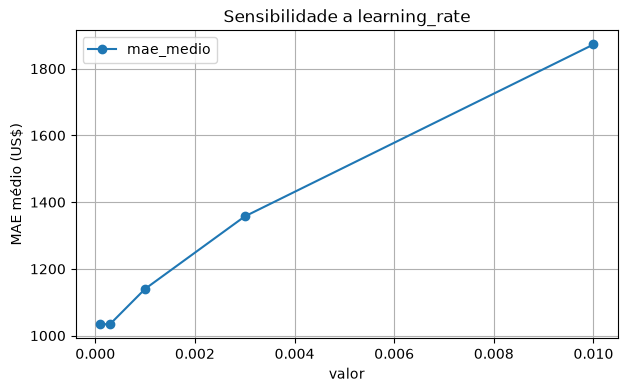

In [30]:
def obter_melhor_configuracao():
    tabelas = []
    if 'resultados_random' in globals():
        tabelas.append(resultados_random.assign(estrategia='Random Search'))
    if 'resultados_tpe' in globals():
        tabelas.append(resultados_tpe.assign(estrategia='TPE'))
    if not tabelas:
        raise RuntimeError('Execute Random Search e TPE antes de escolher a configuração final.')
    tabela = pd.concat(tabelas, ignore_index=True).sort_values('mae_medio')
    linha = tabela.iloc[0]
    parametros = {chave: linha[chave] for chave in ESPACO_BUSCA if chave not in {'epocas', 'neuronios'}}
    parametros.update({f'neuronios_{i}': int(linha[f'neuronios_{i}']) for i in range(1, 4)})
    parametros['n_camadas'] = int(linha['n_camadas'])
    parametros['batch_size'] = int(linha['batch_size'])
    parametros['paciencia'] = int(linha['paciencia'])
    return configurar_rede(parametros), linha

HIPERPARAMETRO = 'learning_rate'
VALORES = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
EXECUTAR_SENSIBILIDADE = True

def executar_sensibilidade(hiperparametro, valores):
    configuracao_base, linha_base = obter_melhor_configuracao()
    registros = []
    for valor in valores:
        configuracao = configuracao_base.copy()
        configuracao[hiperparametro] = valor
        folds = avaliar_configuracao_cv(configuracao, X_cv, y_cv, verbose=0)
        registros.append({
            'hiperparametro': hiperparametro, 'valor': valor,
            'mae_medio': folds['mae'].mean(), 'mae_desvio': folds['mae'].std(),
            'rmse_medio': folds['rmse'].mean(), 'r2_medio': folds['r2'].mean(),
        })
        print(f'{hiperparametro}={valor}: MAE médio = US$ {registros[-1]["mae_medio"]:,.2f}')
    return pd.DataFrame(registros), configuracao_base, linha_base

if EXECUTAR_SENSIBILIDADE:
    resultados_sensibilidade, configuracao_base, linha_base = executar_sensibilidade(HIPERPARAMETRO, VALORES)
    display(resultados_sensibilidade)
    resultados_sensibilidade.plot(x='valor', y='mae_medio', marker='o', figsize=(7, 4), title=f'Sensibilidade a {HIPERPARAMETRO}')
    plt.ylabel('MAE médio (US$)'); plt.grid(True); plt.show()
else:
    print('Sensibilidade não executada. Defina EXECUTAR_SENSIBILIDADE = True.')

#### Interpretação — Andrey de Matos Gonçalves

Entre os cinco valores testados, `1e-4` produziu o menor MAE médio (US$ 1.033,38), seguido de perto por `3e-4` (US$ 1.035,03). A partir de `1e-3`, o erro aumentou progressivamente; com `1e-2`, o MAE chegou a US$ 1.872,51 e também apresentou o maior desvio entre os folds. Isso indica que taxas elevadas tornam as atualizações dos pesos excessivamente grandes e instáveis para este problema. O comportamento é coerente com a importância estimada pelo TPE, que apontou `learning_rate` como o hiperparâmetro de maior impacto. A taxa exata da melhor configuração da Random Search, próxima de `1,8e-4`, permaneceu ligeiramente superior aos cinco pontos da grade, com MAE de US$ 1.027,26.

In [31]:
def executar_sensibilidade_personalizada(integrante, hiperparametro, valores, aplicar_valor):
    """Varia um único hiperparâmetro e mantém toda a configuração vencedora fixa."""
    configuracao_base, linha_base = obter_melhor_configuracao()
    registros = []
    for valor in valores:
        configuracao = configuracao_base.copy()
        configuracao['camadas'] = tuple(configuracao['camadas'])
        aplicar_valor(configuracao, valor)
        folds = avaliar_configuracao_cv(configuracao, X_cv, y_cv, verbose=0)
        registros.append({
            'integrante': integrante, 'hiperparametro': hiperparametro, 'valor': valor,
            'mae_medio': folds['mae'].mean(), 'mae_desvio': folds['mae'].std(),
            'rmse_medio': folds['rmse'].mean(), 'r2_medio': folds['r2'].mean(),
            'epocas_medias': folds['epocas_treinadas'].mean(),
        })
        print(f'{integrante} | {hiperparametro}={valor}: MAE médio = US$ {registros[-1]["mae_medio"]:,.2f}')
    return pd.DataFrame(registros), configuracao_base, linha_base

def exibir_sensibilidade(tabela, titulo, escala_log_x=False):
    display(tabela)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].errorbar(tabela['valor'], tabela['mae_medio'], yerr=tabela['mae_desvio'], marker='o', capsize=4)
    axes[0].set(xlabel='Valor testado', ylabel='MAE médio (US$)', title='Desempenho de validação')
    axes[1].plot(tabela['valor'], tabela['epocas_medias'], marker='o', color='#d95f02')
    axes[1].set(xlabel='Valor testado', ylabel='Épocas médias', title='Custo de treinamento')
    if escala_log_x:
        axes[0].set_xscale('log'); axes[1].set_xscale('log')
    for ax in axes:
        ax.grid(True, alpha=0.3)
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

### 10.2 Felipe Gabriel Souza Libório — tamanho do lote (`batch_size`)

O tamanho do lote controla quantas observações contribuem para cada atualização dos pesos. Serão comparados cinco valores, mantendo fixa a configuração vencedora das buscas.

In [32]:
VALORES_BATCH_SIZE = [16, 32, 64, 128, 256]
resultados_sensibilidade_felipe_gabriel, _, _ = executar_sensibilidade_personalizada(
    'Felipe Gabriel Souza Libório', 'batch_size', VALORES_BATCH_SIZE,
    lambda configuracao, valor: configuracao.update(batch_size=valor),
)
exibir_sensibilidade(
    resultados_sensibilidade_felipe_gabriel,
    'Felipe Gabriel — sensibilidade ao tamanho do lote',
)

Felipe Gabriel Souza Libório | batch_size=16: MAE médio = US$ 1,074.86
Felipe Gabriel Souza Libório | batch_size=32: MAE médio = US$ 1,057.64
Felipe Gabriel Souza Libório | batch_size=64: MAE médio = US$ 1,062.41
Felipe Gabriel Souza Libório | batch_size=128: MAE médio = US$ 1,027.26
Felipe Gabriel Souza Libório | batch_size=256: MAE médio = US$ 1,081.86


#### Interpretação — Felipe Gabriel Souza Libório

| Batch size | MAE médio (US$) | Desvio do MAE | RMSE médio (US$) | R² médio | Épocas médias |
|---:|---:|---:|---:|---:|---:|
| 16 | 1.074,86 | 22,53 | 1.877,33 | 0,9631 | 35,3 |
| 32 | 1.057,64 | 36,51 | 1.754,44 | 0,9678 | 47,3 |
| 64 | 1.062,41 | 67,70 | 1.700,82 | 0,9697 | 62,7 |
| **128** | **1.027,26** | **13,79** | **1.632,18** | **0,9721** | **80,0** |
| 256 | 1.081,86 | 33,72 | 1.722,40 | 0,9690 | 80,0 |

![Sensibilidade ao tamanho do lote](figuras/sensibilidade_felipe_gabriel.png)

O efeito não foi monotônico: reduzir ou aumentar o lote em relação à configuração vencedora piorou o MAE. `batch_size=128` apresentou simultaneamente o menor erro e o menor desvio entre folds. Lotes menores encerraram em menos épocas, mas realizam mais atualizações em cada época; portanto, menos épocas não significa necessariamente menor tempo computacional. O lote 256 atingiu o limite de 80 épocas e ainda apresentou resultado inferior. Para este dataset, 128 ofereceu o melhor equilíbrio entre desempenho e estabilidade.

### 10.3 Felipe Vieira Brazão e Silva — neurônios na primeira camada oculta

Esta análise altera somente a largura da primeira camada oculta. As demais camadas e todos os outros hiperparâmetros permanecem iguais aos da melhor configuração encontrada.

In [33]:
def alterar_primeira_camada(configuracao, valor):
    camadas = list(configuracao['camadas'])
    camadas[0] = valor
    configuracao['camadas'] = tuple(camadas)

VALORES_NEURONIOS_PRIMEIRA_CAMADA = [32, 64, 128, 256, 512]
resultados_sensibilidade_felipe_vieira, _, _ = executar_sensibilidade_personalizada(
    'Felipe Vieira Brazão e Silva', 'neuronios_primeira_camada',
    VALORES_NEURONIOS_PRIMEIRA_CAMADA, alterar_primeira_camada,
)
exibir_sensibilidade(
    resultados_sensibilidade_felipe_vieira,
    'Felipe Vieira — sensibilidade aos neurônios da primeira camada',
)

Felipe Vieira Brazão e Silva | neuronios_primeira_camada=32: MAE médio = US$ 1,148.24
Felipe Vieira Brazão e Silva | neuronios_primeira_camada=64: MAE médio = US$ 1,139.12
Felipe Vieira Brazão e Silva | neuronios_primeira_camada=128: MAE médio = US$ 1,033.53
Felipe Vieira Brazão e Silva | neuronios_primeira_camada=256: MAE médio = US$ 1,027.26
Felipe Vieira Brazão e Silva | neuronios_primeira_camada=512: MAE médio = US$ 1,028.36


#### Interpretação — Felipe Vieira Brazão e Silva

| Neurônios na primeira camada | MAE médio (US$) | Desvio do MAE | RMSE médio (US$) | R² médio | Épocas médias |
|---:|---:|---:|---:|---:|---:|
| 32 | 1.148,24 | 51,38 | 2.047,95 | 0,9560 | 80,0 |
| 64 | 1.139,12 | 46,47 | 1.955,36 | 0,9598 | 80,0 |
| 128 | 1.033,53 | 12,97 | 1.706,93 | 0,9695 | 80,0 |
| **256** | **1.027,26** | 13,79 | **1.632,18** | **0,9721** | 80,0 |
| 512 | 1.028,36 | **9,51** | 1.655,52 | 0,9713 | 71,3 |

![Sensibilidade aos neurônios da primeira camada](figuras/sensibilidade_felipe_vieira.png)

As redes com 32 e 64 neurônios tiveram erros consideravelmente maiores e chegaram ao limite de 80 épocas, indicando capacidade insuficiente ou convergência lenta. O salto para 128 neurônios reduziu fortemente o MAE. O menor erro ocorreu com 256 neurônios, enquanto 512 ficou praticamente empatado e apresentou menor dispersão, mas dobrou a largura da camada sem ganho relevante de desempenho. Assim, 256 neurônios permanece a escolha mais parcimoniosa entre as opções de melhor resultado.

### 10.4 Gabriel Coelho Goes — paciência do Early Stopping

A paciência determina quantas épocas sem melhora da perda de validação são toleradas antes da interrupção. Serão comparados cinco valores, mantendo os demais parâmetros fixos.

In [34]:
VALORES_PACIENCIA = [4, 8, 12, 16, 20]
resultados_sensibilidade_gabriel, _, _ = executar_sensibilidade_personalizada(
    'Gabriel Coelho Goes', 'paciencia', VALORES_PACIENCIA,
    lambda configuracao, valor: configuracao.update(paciencia=valor),
)
exibir_sensibilidade(
    resultados_sensibilidade_gabriel,
    'Gabriel — sensibilidade à paciência do Early Stopping',
)

Gabriel Coelho Goes | paciencia=4: MAE médio = US$ 1,027.26
Gabriel Coelho Goes | paciencia=8: MAE médio = US$ 1,027.26
Gabriel Coelho Goes | paciencia=12: MAE médio = US$ 1,027.26
Gabriel Coelho Goes | paciencia=16: MAE médio = US$ 1,027.26
Gabriel Coelho Goes | paciencia=20: MAE médio = US$ 1,027.26


#### Interpretação — Gabriel Coelho Goes

| Paciência | MAE médio (US$) | Desvio do MAE | RMSE médio (US$) | R² médio | Épocas médias |
|---:|---:|---:|---:|---:|---:|
| **4** | **1.027,26** | 13,79 | **1.632,18** | **0,9721** | **77,3** |
| 8 | 1.027,26 | 13,79 | 1.632,18 | 0,9721 | 79,0 |
| 12 | 1.027,26 | 13,79 | 1.632,18 | 0,9721 | 80,0 |
| 16 | 1.027,26 | 13,79 | 1.632,18 | 0,9721 | 80,0 |
| 20 | 1.027,26 | 13,79 | 1.632,18 | 0,9721 | 80,0 |

![Sensibilidade à paciência do Early Stopping](figuras/sensibilidade_gabriel.png)

Os cinco valores levaram aos mesmos melhores pesos restaurados e, consequentemente, às mesmas métricas de validação. A diferença apareceu apenas no número de épocas: paciência 4 encerrou em média após 77,3 épocas, enquanto valores a partir de 12 atingiram o limite de 80. Portanto, nesta configuração a paciência teve impacto praticamente nulo no desempenho; o teto de épocas tornou-se o fator limitante. Entre os valores avaliados, paciência 4 foi a alternativa mais econômica, embora a diferença de custo tenha sido pequena.

## 11. Análise da variável `mmr`

O `mmr` representa a avaliação do Manheim Market Report, indicador de preços no mercado atacadista calculado a partir de transações recentes. Por já sintetizar informação de mercado diretamente relacionada ao preço de venda, ele pode tornar a previsão excessivamente fácil. A variável só é legítima no modelo se sua avaliação estiver disponível antes da venda no cenário real de uso.

Para medir sua influência sem consultar novamente o holdout de teste, foram comparados nos mesmos três folds: (1) o próprio `mmr` usado como previsão; (2) a MLP vencedora com `mmr`; e (3) a mesma MLP, com todos os hiperparâmetros fixos, após remover `mmr`. Fonte sobre o significado do indicador: <https://site.manheim.com/en/services/valuation>.

In [35]:
X_cv_sem_mmr = X_cv.drop(columns=['mmr'])
numericas_sem_mmr = X_cv_sem_mmr.select_dtypes(include=np.number).columns.tolist()
categoricas_sem_mmr = X_cv_sem_mmr.select_dtypes(exclude=np.number).columns.tolist()
preprocessador_sem_mmr = ColumnTransformer(
    transformers=[
        ('numericas', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('float32', FunctionTransformer(lambda x: x.astype(np.float32))),
        ]), numericas_sem_mmr),
        ('categoricas', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(
                handle_unknown='infrequent_if_exist', min_frequency=100, max_categories=50,
                sparse_output=False, dtype=np.float32
            )),
        ]), categoricas_sem_mmr),
    ],
    remainder='drop',
)

configuracao_vencedora, linha_vencedora = obter_melhor_configuracao()
folds_sem_mmr = avaliar_configuracao_cv(
    configuracao_vencedora, X_cv_sem_mmr, y_cv,
    preprocessador_base=preprocessador_sem_mmr, verbose=0,
)

registros_baseline_mmr = []
kfold_mmr = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEMENTE)
for fold, (idx_treino, idx_validacao) in enumerate(kfold_mmr.split(X_cv), start=1):
    mediana_mmr = X_cv.iloc[idx_treino]['mmr'].median()
    previsoes_mmr = X_cv.iloc[idx_validacao]['mmr'].fillna(mediana_mmr)
    y_validacao = y_cv.iloc[idx_validacao]
    registros_baseline_mmr.append({
        'fold': fold,
        'mae': mean_absolute_error(y_validacao, previsoes_mmr),
        'rmse': root_mean_squared_error(y_validacao, previsoes_mmr),
        'r2': r2_score(y_validacao, previsoes_mmr),
    })
folds_baseline_mmr = pd.DataFrame(registros_baseline_mmr)

comparacao_mmr = pd.DataFrame([
    {
        'modelo': 'Baseline: previsão = mmr',
        'mae_medio': folds_baseline_mmr['mae'].mean(),
        'mae_desvio': folds_baseline_mmr['mae'].std(),
        'rmse_medio': folds_baseline_mmr['rmse'].mean(),
        'r2_medio': folds_baseline_mmr['r2'].mean(),
    },
    {
        'modelo': 'MLP com mmr',
        'mae_medio': linha_vencedora['mae_medio'],
        'mae_desvio': linha_vencedora['mae_desvio'],
        'rmse_medio': linha_vencedora['rmse_medio'],
        'r2_medio': linha_vencedora['r2_medio'],
    },
    {
        'modelo': 'MLP sem mmr',
        'mae_medio': folds_sem_mmr['mae'].mean(),
        'mae_desvio': folds_sem_mmr['mae'].std(),
        'rmse_medio': folds_sem_mmr['rmse'].mean(),
        'r2_medio': folds_sem_mmr['r2'].mean(),
    },
]).set_index('modelo')
display(comparacao_mmr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
posicoes = np.arange(len(comparacao_mmr)); largura = 0.36
axes[0].bar(posicoes - largura / 2, comparacao_mmr['mae_medio'], largura, label='MAE')
axes[0].bar(posicoes + largura / 2, comparacao_mmr['rmse_medio'], largura, label='RMSE')
axes[0].set_xticks(posicoes, ['Baseline MMR', 'MLP com MMR', 'MLP sem MMR'])
axes[0].set(ylabel='Erro médio (US$)', title='Erros de validação cruzada')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(posicoes, comparacao_mmr['r2_medio'], color=['#7570b3', '#1b9e77', '#d95f02'])
axes[1].set_xticks(posicoes, ['Baseline MMR', 'MLP com MMR', 'MLP sem MMR'])
axes[1].set(ylabel='R² médio', title='Variância explicada', ylim=(0, 1))
axes[1].grid(axis='y', alpha=0.3)
fig.suptitle('Ablação da variável MMR')
plt.tight_layout(); plt.show()

                        mae_medio  mae_desvio  rmse_medio  r2_medio
modelo                                                               
Baseline: previsão = mmr  1085.969274    7.183523  1716.977848  0.969161
MLP com mmr               1027.257935   13.786657  1632.175781  0.972121
MLP sem mmr               1880.528320    9.947332  3660.886719  0.859746

| Abordagem | MAE médio (US$) | Desvio do MAE | RMSE médio (US$) | R² médio |
|---|---:|---:|---:|---:|
| Baseline: previsão = `mmr` | 1.085,97 | **7,18** | 1.716,98 | 0,9692 |
| **MLP com `mmr`** | **1.027,26** | 13,79 | **1.632,18** | **0,9721** |
| MLP sem `mmr` | 1.880,53 | 9,95 | 3.660,89 | 0,8597 |

![Comparação da ablação de MMR](figuras/ablacao_mmr.png)

O próprio `mmr` já é um baseline muito forte. A MLP com essa variável reduziu o MAE em US$ 58,71, aproximadamente 5,4%, em relação a simplesmente usar a avaliação MMR como preço previsto. Isso mostra que os demais atributos adicionam informação, mas o ganho incremental sobre o indicador de mercado é relativamente pequeno.

Ao remover `mmr` e manter fixa a arquitetura vencedora, o MAE aumentou em US$ 853,27, ou aproximadamente 83,1%, e o R² caiu de 0,9721 para 0,8597. Portanto, uma parcela substancial da precisão do modelo depende dessa avaliação prévia de mercado. O resultado sem `mmr` não representa necessariamente a melhor MLP possível sem essa variável, pois os hiperparâmetros não foram reajustados; trata-se de uma ablação controlada para medir sua contribuição sob a mesma configuração.

**Decisão metodológica:** `mmr` será mantido no modelo final somente sob a hipótese explícita de que esse indicador já existe e está disponível antes da venda no cenário de aplicação. Nesse caso, ele é um preditor legítimo e a tarefa da MLP é refinar a estimativa de mercado usando outras características. Se o objetivo for criar uma avaliação independente sem acesso a uma estimativa prévia de preço, `mmr` deverá ser excluído e o modelo precisará ser novamente otimizado. Assim, não classificamos automaticamente a variável como vazamento, mas reconhecemos que ela funciona como um forte proxy do alvo e limita a interpretação do ganho obtido pela rede.

Todo esse diagnóstico foi realizado na validação cruzada do conjunto de treino. O holdout permaneceu fora da ablação e não foi usado para escolher entre manter ou remover a variável.

## 12. Treinamento final e teste reservado

A configuração com menor MAE médio é treinada novamente usando somente os dados de treino. O conjunto de teste é transformado e avaliado uma única vez nesta etapa final.

In [36]:
EXECUTAR_AVALIACAO_FINAL = True

def treinar_e_avaliar_final():
    configuracao, linha_base = obter_melhor_configuracao()
    faixas = pd.qcut(y_treino, q=10, labels=False, duplicates='drop')
    X_ajuste, X_parada, y_ajuste, y_parada = train_test_split(
        X_treino, y_treino, test_size=0.10, random_state=SEMENTE, stratify=faixas
    )
    prep_final = clone(preprocessador)
    X_ajuste_proc = prep_final.fit_transform(X_ajuste)
    X_parada_proc = prep_final.transform(X_parada)
    X_teste_proc = prep_final.transform(X_teste)
    modelo_final = criar_mlp(X_ajuste_proc.shape[1], **{
        chave: configuracao[chave] for chave in ['camadas', 'ativacao', 'learning_rate', 'otimizador']
    })
    historico_final = modelo_final.fit(
        X_ajuste_proc, np.log1p(y_ajuste), validation_data=(X_parada_proc, np.log1p(y_parada)),
        epochs=configuracao['epocas'], batch_size=configuracao['batch_size'],
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=configuracao['paciencia'], restore_best_weights=True), tf.keras.callbacks.TerminateOnNaN()],
        verbose=0,
    )
    limite_log = np.log1p(y_ajuste.max() * 2)
    previsoes_log = np.nan_to_num(modelo_final.predict(X_teste_proc, verbose=0).ravel(), nan=0.0, posinf=limite_log, neginf=0.0)
    previsoes = np.expm1(np.clip(previsoes_log, 0.0, limite_log))
    metricas = pd.Series({
        'MAE (US$)': mean_absolute_error(y_teste, previsoes),
        'RMSE (US$)': root_mean_squared_error(y_teste, previsoes),
        'R²': r2_score(y_teste, previsoes),
        'épocas treinadas': len(historico_final.history['loss']),
    })
    return modelo_final, metricas, linha_base, previsoes, historico_final

if EXECUTAR_AVALIACAO_FINAL:
    modelo_final, metricas_finais, melhor_linha, previsoes_teste, historico_final = treinar_e_avaliar_final()
    display(metricas_finais.to_frame('resultado'))
else:
    print('Avaliação final não executada. Defina EXECUTAR_AVALIACAO_FINAL = True somente após a sensibilidade.')

,resultado
MAE (US$),1065.154785
RMSE (US$),1652.573853
R²,0.971025
épocas treinadas,75.000000


## 13. Diagnóstico de overfitting e underfitting

As curvas abaixo usam apenas o subconjunto de ajuste e a validação interna criada dentro do conjunto de treino. O holdout de teste não foi usado para escolher a época. Como o modelo aprende `log1p(sellingprice)`, as perdas desta seção estão na escala logarítmica; as métricas finais em dólares permanecem na seção anterior.

In [37]:
historico_final_df = pd.DataFrame(historico_final.history)
melhor_indice = int(historico_final_df['val_loss'].idxmin())
melhor_epoca = melhor_indice + 1
diagnostico_ajuste = pd.Series({
    'épocas treinadas': len(historico_final_df),
    'melhor época pela perda de validação': melhor_epoca,
    'MSE treino na melhor época': historico_final_df.loc[melhor_indice, 'loss'],
    'MSE validação na melhor época': historico_final_df.loc[melhor_indice, 'val_loss'],
    'MAE log treino na melhor época': historico_final_df.loc[melhor_indice, 'mae'],
    'MAE log validação na melhor época': historico_final_df.loc[melhor_indice, 'val_mae'],
})
display(diagnostico_ajuste.to_frame('resultado'))

epocas = np.arange(1, len(historico_final_df) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epocas, historico_final_df['loss'], label='Treino')
axes[0].plot(epocas, historico_final_df['val_loss'], label='Validação')
axes[0].axvline(melhor_epoca, color='black', linestyle='--', alpha=0.7, label='Melhor época')
axes[0].set(xlabel='Época', ylabel='MSE em log1p(preço)', title='Curva de perda')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(epocas, historico_final_df['mae'], label='Treino')
axes[1].plot(epocas, historico_final_df['val_mae'], label='Validação')
axes[1].axvline(melhor_epoca, color='black', linestyle='--', alpha=0.7, label='Melhor época')
axes[1].set(xlabel='Época', ylabel='MAE em log1p(preço)', title='Curva de MAE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
fig.suptitle('Diagnóstico de ajuste do modelo final')
plt.tight_layout(); plt.show()

                                      resultado
épocas treinadas                      75.000000
melhor época pela perda de validação  63.000000
MSE treino na melhor época             0.037444
MSE validação na melhor época           0.041483
MAE log treino na melhor época          0.111206
MAE log validação na melhor época        0.121464

![Curvas de treinamento e validação](figuras/curvas_modelo_final.png)

O treinamento durou 75 épocas, e a menor perda de validação ocorreu na época 63. Nessa época, o MSE foi 0,03744 no ajuste e 0,04148 na validação, uma diferença relativa de aproximadamente 10,8%. O MAE na escala logarítmica foi 0,11121 no ajuste e 0,12146 na validação, mantendo uma separação moderada entre as curvas.

Até a época 63, as perdas de treino e validação diminuíram de forma consistente, o que não caracteriza underfitting forte. Após esse ponto, a perda de treino continuou caindo, de 0,03744 para 0,03645, enquanto a perda de validação apresentou uma elevação pequena, de 0,041483 para 0,041574, cerca de 0,22%. Esse afastamento indica o início de um overfitting leve e tardio, não um sobreajuste severo.

O `EarlyStopping`, com restauração dos melhores pesos, interrompeu o treinamento após 12 épocas sem melhora do `val_loss` e recuperou o estado da época 63. Portanto, o mecanismo cumpriu sua função de impedir que o início do sobreajuste afetasse o modelo usado no teste. A proximidade entre o MAE de validação da configuração selecionada (US$ 1.027,26) e o MAE final no holdout (US$ 1.065,15) também sugere generalização consistente.

**Conclusão:** o modelo não apresenta evidência de underfitting relevante nem de overfitting severo. Há um leve sobreajuste no final do treinamento, adequadamente controlado pelo Early Stopping. Essa conclusão se refere ao modelo com `mmr`; a força preditiva dessa variável ainda deve ser considerada na interpretação global do desempenho.

## 14. Conclusões gerais

O trabalho cumpriu o objetivo de preparar um dataset real de regressão, construir uma MLP, comparar duas estratégias de ajuste sob o mesmo orçamento, investigar individualmente hiperparâmetros e avaliar uma única configuração final no conjunto de teste reservado.

### Respostas às questões da atividade

**Como Random Search e TPE se comportaram com o mesmo orçamento? Qual estratégia encontrou a melhor configuração?**  
A Random Search encontrou a melhor configuração isolada logo na tentativa 2, com MAE médio de validação de US$ 1.027,26. O TPE obteve melhor valor de US$ 1.072,11. Portanto, a Random Search venceu pelo critério principal, com vantagem aproximada de 4,2%. Entretanto, o TPE foi mais consistente no conjunto das 25 tentativas: apresentou média, mediana e dispersão de MAE melhores que as da busca aleatória e concentrou progressivamente as avaliações em uma região de bom desempenho. Neste orçamento reduzido, a adaptação do TPE aumentou a frequência de configurações boas, mas não encontrou o ponto excepcional alcançado pela Random Search.

**Qual hiperparâmetro apresentou maior impacto? O resultado foi coerente com a importância estimada pelo TPE?**  
O `learning_rate` apresentou o maior impacto. Sua análise de sensibilidade produziu uma amplitude de aproximadamente US$ 839 no MAE, enquanto as amplitudes de neurônios da primeira camada e batch size foram de aproximadamente US$ 121 e US$ 55, respectivamente; a paciência não alterou o MAE nessa configuração. Esse resultado é coerente com a importância do TPE, que classificou `learning_rate` como o fator dominante. Taxas elevadas tornaram o treinamento instável, enquanto valores próximos de `1e-4` produziram os menores erros.

**O modelo apresentou overfitting ou underfitting?**  
Não foram encontrados sinais de underfitting relevante ou overfitting severo. A melhor perda de validação ocorreu na época 63. Depois disso, a perda de treino continuou diminuindo e a de validação subiu apenas 0,22%, caracterizando um sobreajuste leve e tardio. O Early Stopping encerrou o treinamento e restaurou os pesos da melhor época, impedindo que essa divergência afetasse o modelo avaliado no teste.

**Quais conclusões podem ser tiradas sobre o comportamento do modelo?**  
A configuração selecionada foi uma MLP com duas camadas ocultas de 256 e 128 neurônios, ativação `tanh`, RMSprop, learning rate de aproximadamente `1,8e-4`, batch size 128 e paciência 12. No holdout, ela obteve MAE de US$ 1.065,15, RMSE de US$ 1.652,57 e R² de 0,9710. A proximidade entre o MAE de validação e o de teste indica generalização consistente para uma divisão aleatória estratificada do mesmo conjunto de dados.

### Papel da variável `mmr`

O desempenho elevado precisa ser interpretado à luz do `mmr`. Usar somente essa variável como previsão já obteve MAE de US$ 1.085,97 na validação cruzada. A MLP com `mmr` melhorou esse baseline em aproximadamente 5,4%, mas sua remoção elevou o MAE para US$ 1.880,53. Assim, a rede consegue refinar a avaliação de mercado, porém grande parte de sua precisão depende desse indicador. O modelo final é adequado quando o `mmr` está disponível antes da venda; ele não deve ser apresentado como uma avaliação independente baseada apenas nas características brutas do veículo.

### Limitações e trabalhos futuros

- A busca utilizou uma amostra de 100.000 observações do treino para manter o custo computacional viável.
- A ablação sem `mmr` manteve a configuração otimizada com a variável; uma busca específica sem `mmr` poderia melhorar aquele resultado.
- A divisão foi aleatória e estratificada por preço. Uma validação temporal por `saledate` poderia avaliar melhor a generalização para vendas futuras e mudanças de mercado.
- Os parâmetros de camadas inativas foram sorteados nas duas estratégias. Uma busca condicional poderia tornar o TPE e sua importância mais precisos.
- Estudos futuros podem avaliar outras formas de representar categorias de alta cardinalidade e comparar o custo computacional das configurações, preservando o escopo de uma MLP densa.

Em síntese, a MLP apresentou bom desempenho e generalização no cenário avaliado, a Random Search forneceu a melhor configuração individual e o TPE apresentou maior consistência global. As sensibilidades confirmaram que a taxa de aprendizado foi a decisão de otimização mais crítica. A principal ressalva é que o resultado deve ser comunicado como um refinamento de uma forte avaliação de mercado fornecida por `mmr`, e não como uma previsão completamente independente.